<a href="https://www.kaggle.com/code/twishhasoni/classification-using-mnist-dataset?scriptVersionId=334230233" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Learning Classification from author Aurélien Géron's book - hands on machine learning with scikit-learn, keras and tensorflow.

Hands-On
Machine Learning with Scikit-Learn, Keras, and TensorFlow by Aurélien
Géron. Copyright 2023 Aurélien Géron, 978-1-098-12597-4.

## Binary Classifier

In [1]:
# sklearn.datasets package contains few functions to fetch popular dataseets
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)
# print(mnist)
X, y = mnist.data, mnist.target
print(X)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [2]:
print(X.shape)

(70000, 784)


In [3]:
print(y)

['5' '0' '4' ... '4' '5' '6']


In [4]:
print(y.shape)

(70000,)


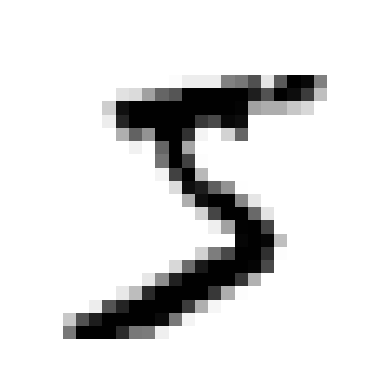

In [5]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
def plot_digit(image_data):
    image = image_data.reshape(28,28)
    # custom_cmap = ListedColormap(['red', 'green'])
    plt.imshow(image, cmap='binary')
    plt.axis('off')

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [6]:
print(y[0])

5


In [7]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [8]:
y_train_5 = (y_train == '5')
y_test_5 = (y_test == '5')
# print(y_train_5)

In [9]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [10]:
sgd_clf.predict([X[8]])

array([False])

## Performance Measure

### 1. Measuring Accuracy using cross-validation

In [11]:
from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')


array([0.95035, 0.96035, 0.9604 ])

In [12]:
from sklearn.dummy import DummyClassifier
dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train)))

False


In [13]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.90965, 0.90965, 0.90965])

### 2. Confusion Matrix

In [14]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
print(y_train_pred)
print(y_train_pred.shape)

[ True False False ...  True False False]
(60000,)


In [15]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [16]:
y_train_perfect_predictions = y_train_5
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

### 3. Precision and Recall

In [17]:
from sklearn.metrics import precision_score, recall_score
print(f"Precision score: {precision_score(y_train_5, y_train_pred)}")
print(f"Recall score: {recall_score(y_train_5, y_train_pred)}")

Precision score: 0.8370879772350012
Recall score: 0.6511713705958311


In [18]:
from sklearn.metrics import f1_score
print(f"F1 score: {f1_score(y_train_5, y_train_pred)}")

F1 score: 0.7325171197343847


### 4. Precision/Recall Trade-off

In [19]:
y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [20]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[ True]


In [21]:
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
print(y_some_digit_pred)

[False]


In [22]:
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method='decision_function')
print(y_scores)

[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


In [23]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

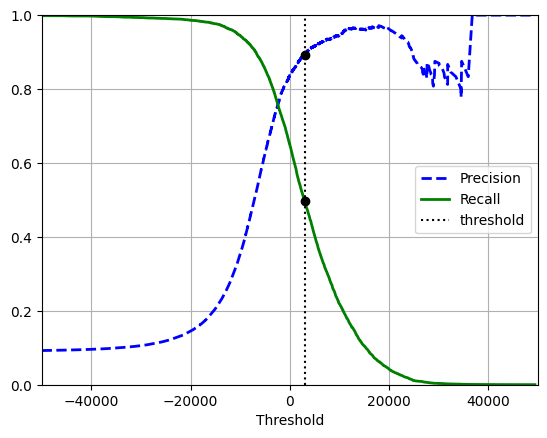

In [24]:
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall', linewidth=2)
plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='threshold')

idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
plt.plot(thresholds[idx], precisions[idx], "ko")
plt.plot(thresholds[idx], recalls[idx], "ko")

plt.grid(True)
plt.legend(loc='center right')
plt.xlim(-50000, 50000)
plt.ylim(0.0, 1.0)
plt.xlabel("Threshold")
plt.show()

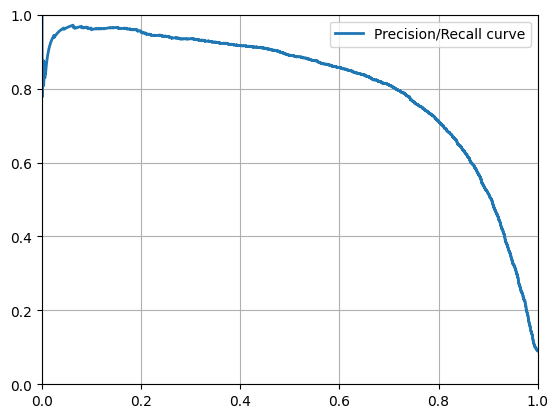

In [25]:
plt.plot(recalls, precisions, linewidth=2, label='Precision/Recall curve')
plt.grid(True)
plt.legend()
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.show()

In [26]:
idx_for_90_precision = (precisions >= 0.9).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [27]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [28]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [29]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

### 5. The ROC Curve

In [30]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)


In [31]:
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

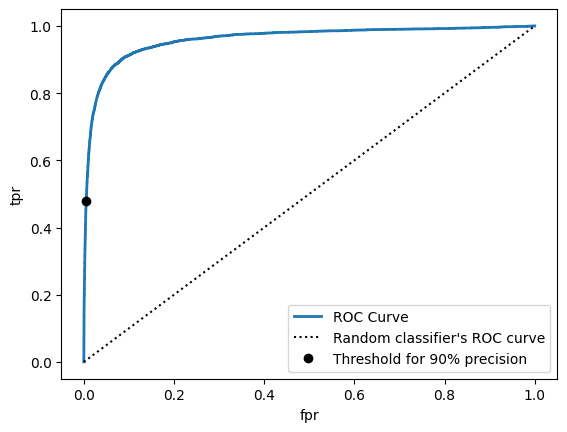

In [32]:
plt.plot(fpr, tpr, linewidth=2, label='ROC Curve')
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
plt.legend()
plt.xlabel('fpr')
plt.ylabel('tpr')
plt.show()

In [33]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

In [34]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3 , method='predict_proba')

In [35]:
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [36]:
y_scores_forest = y_probas_forest[:,1]
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

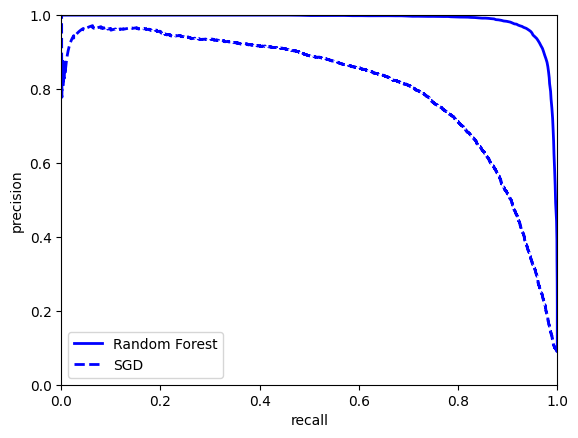

In [37]:
plt.plot(recalls_forest, precisions_forest, 'b-', linewidth=2, label='Random Forest')
plt.plot(recalls, precisions, 'b--', linewidth=2, label='SGD')
plt.legend(loc='lower left')
plt.xlim(0.0,1.0)
plt.ylim(0.0,1.0)
plt.xlabel('recall')
plt.ylabel('precision')
plt.show()

In [38]:
y_train_pred_forest = y_probas_forest[:,1] >= 0.5 # postive probas >= 50%
f1_score(y_train_5, y_train_pred_forest)


0.9274509803921569

In [39]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

In [40]:
print(f"Precision score: {precision_score(y_train_5, y_train_pred_forest)}")
print(f"Recall score: {recall_score(y_train_5, y_train_pred_forest)}")

Precision score: 0.9897468089558485
Recall score: 0.8725327430363402


## MULTICLASS CLASSIFICATION

In [41]:
from sklearn.svm import SVC
svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000])

SVC(random_state=42)

In [42]:
some_digit = X[0]

In [43]:
svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [44]:
some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [45]:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

In [46]:
svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [47]:
svm_clf.classes_[class_id]

'5'

In [48]:
from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

OneVsRestClassifier(estimator=SVC(random_state=42))

In [49]:
ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [50]:
len(ovr_clf.estimators_)

10

In [51]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [52]:
sgd_clf.decision_function([some_digit]).round(2)

array([[-31893.03, -34419.69,  -9530.64,   1823.73, -22320.15,  -1385.8 ,
        -26188.91, -16147.51,  -4604.35, -12050.77]])

In [53]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring='accuracy')

array([0.87365, 0.85835, 0.8689 ])

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))
cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring='accuracy')


array([0.8983, 0.891 , 0.9018])

## Error Analysis

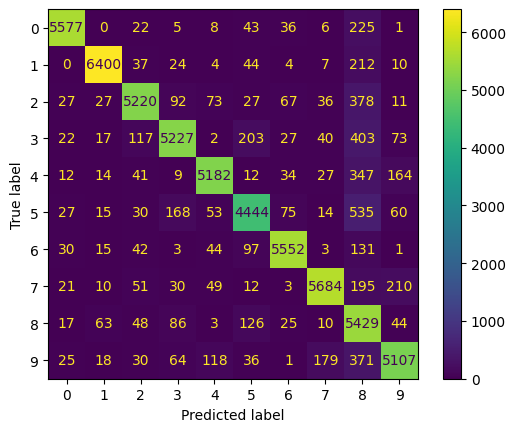

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

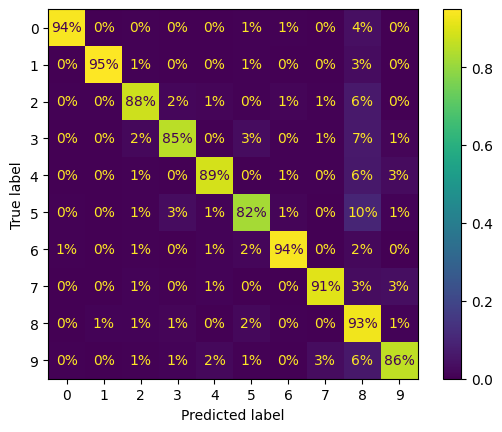

In [56]:
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize='true', values_format='.0%')
plt.show()

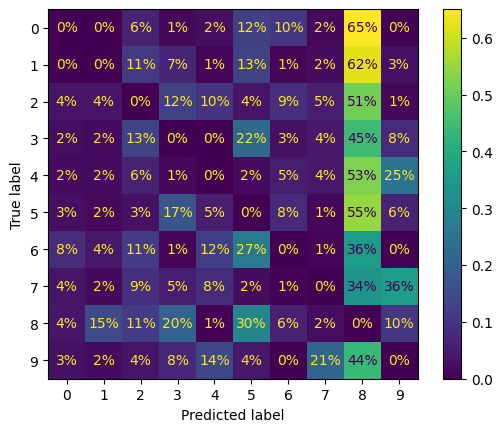

In [57]:
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
sample_weight=sample_weight,
normalize="true", values_format=".0%")
plt.show()

In [58]:
cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]

## MULTILABEL CLASSIFICATION

In [59]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
some_digit = X[0]
y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)
knn_clf.predict([some_digit])

array([[False,  True]])

In [60]:
from sklearn.model_selection import cross_val_predict
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

In [61]:
from sklearn.metrics import f1_score
f1_score(y_multilabel, y_train_knn_pred, average='macro')

0.9764102655606048

In [62]:
f1_score(y_multilabel, y_train_knn_pred, average='weighted')

0.9778357403921755

In [63]:
from sklearn.svm import SVC
from sklearn.multioutput import ClassifierChain
chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

ClassifierChain(base_estimator=SVC(), cv=3, random_state=42)

In [64]:
chain_clf.predict([some_digit])

array([[0., 1.]])

## Multioutput Classification

In [65]:
import numpy  as np
np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

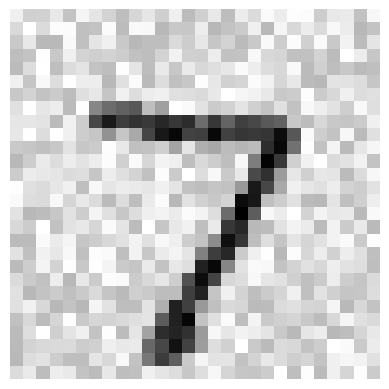

In [66]:
plot_digit(X_test_mod[0])
plt.show()

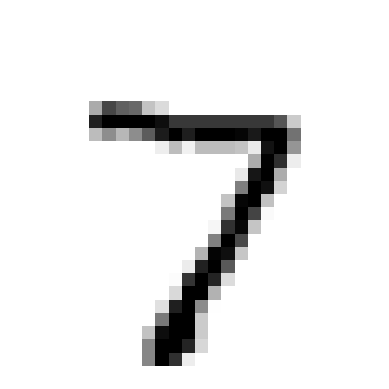

In [67]:
plot_digit(y_test_mod[0])
plt.show()

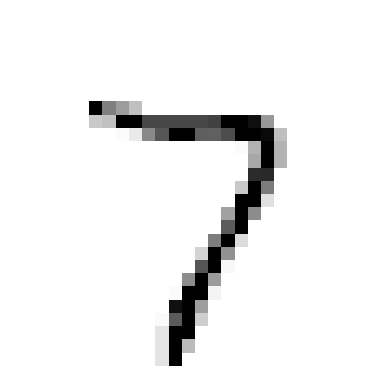

In [68]:
from sklearn.neighbors import KNeighborsClassifier
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()